# Fraud Detection System

## Introduction

Fraud detection refers to the process of identifying suspicious or fraudulent financial transactions. Financial institutions face significant losses due to fraudulent activities, making fraud detection an important problem.

Machine Learning techniques help automate fraud detection by analyzing transaction patterns and identifying suspicious behavior efficiently.

In this project, a Fraud Detection System is developed using the IEEE-CIS Fraud Detection dataset. The project includes data preprocessing, handling missing values, feature encoding, balancing data using SMOTE, model training using XGBoost, and performance evaluation.


In [1]:
!pip install xgboost imbalanced-learn

Importing Libraries

The required Python libraries are imported to perform data processing, machine learning, and visualization tasks.

Pandas and NumPy are used for handling tabular data and numerical operations. Matplotlib is used for visualization. Scikit-learn provides preprocessing and evaluation tools, while XGBoost is used for classification. SMOTE is used to handle class imbalance in fraud detection data.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

Dataset Loading and Merging

The IEEE-CIS Fraud Detection dataset consists of two files: transaction data and identity data. These datasets are merged using the TransactionID column to create a complete dataset for fraud detection analysis.

This helps combine transaction details with user identity information for better prediction performance.

In [3]:
transaction = pd.read_csv('/content/train_transaction.csv')
identity = pd.read_csv('/content/train_identity.csv')
data = transaction.merge(identity, on='TransactionID', how='left')
print("Dataset Shape:", data.shape)
data.head()

Dataset Shape: (25552, 434)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


Data Preprocessing

Real-world datasets often contain missing values, which may affect model performance. In this step, columns with excessive missing values are removed.

Numerical missing values are filled using the median, while categorical missing values are filled using the mode to improve data quality and maintain consistency.

In [4]:
data = data.loc[:, data.isnull().mean() < 0.5]
for col in data.select_dtypes(include=np.number).columns:
    data[col] = data[col].fillna(data[col].median())
for col in data.select_dtypes(include='object').columns:
    data[col] = data[col].fillna(data[col].mode()[0])
print("Missing values handled")
print(data.shape)

Missing values handled
(25552, 185)


Feature Encoding

Machine Learning models cannot directly process text-based categorical data. Therefore, categorical variables are converted into numerical format using Label Encoding.

This transformation helps the model understand and process categorical information efficiently.

In [5]:
label_encoder = LabelEncoder()
for col in data.select_dtypes(include='object').columns:
    data[col] = label_encoder.fit_transform(data[col])
print("Encoding completed")

Encoding completed


Train-Test Split

The dataset is divided into training and testing sets. The training dataset is used to train the model, while the testing dataset is used to evaluate performance.

An 80-20 split ratio is used to ensure proper evaluation of the machine learning model.

In [6]:
X = data.drop(['isFraud'], axis=1)
y = data['isFraud']
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (20441, 184)
Test shape: (5111, 184)


Handling Imbalanced Data using SMOTE

Fraud detection datasets are usually imbalanced because fraudulent transactions occur less frequently than normal transactions.

SMOTE (Synthetic Minority Oversampling Technique) is applied to balance the dataset by increasing minority class samples, helping the model improve fraud detection performance.

In [7]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train,y_train)
print("SMOTE applied")
print(y_train_smote.value_counts())

SMOTE applied
isFraud
1    19871
0    19871
Name: count, dtype: int64


Model Training using XGBoost

XGBoost is used as the primary classification algorithm for fraud detection. It is an efficient gradient boosting algorithm that performs well on tabular datasets.

The model is trained using the processed and balanced training dataset to identify fraudulent transactions.

In [8]:
model = XGBClassifier(
    n_estimators=50,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)
model.fit(X_train_smote, y_train_smote)
print("Model trained successfully")

Model trained successfully


Model Prediction

After training, the model is used to predict whether a transaction is fraudulent or legitimate using the testing dataset.

In [9]:
y_pred = model.predict(X_test)
print("Prediction completed")

Prediction completed


Model Evaluation

The model performance is evaluated using metrics such as Accuracy, Precision, Recall, F1 Score, and AUC-ROC Score.

These metrics help measure the effectiveness of fraud detection and overall model performance.

In [10]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9671297202113089
Precision: 0.4267515923566879
Recall: 0.46206896551724136
F1 Score: 0.44370860927152317


Confusion Matrix

A confusion matrix is used to visualize model predictions by comparing actual values with predicted values.

This helps identify correctly predicted transactions and classification errors.

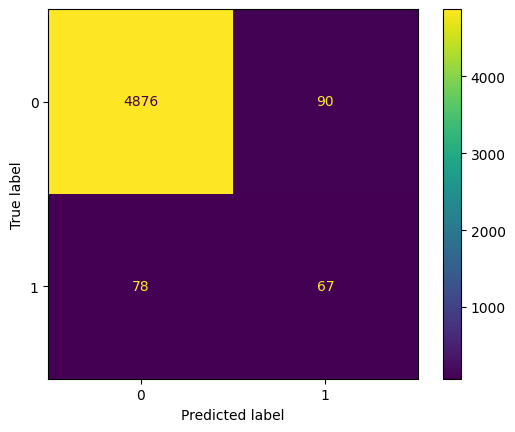

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

AUC-ROC Score

The AUC-ROC (Area Under the Receiver Operating Characteristic Curve) score is used to evaluate how well the model distinguishes between fraudulent and non-fraudulent transactions.

An AUC score ranges from 0 to 1, where:

1.0 indicates perfect classification

0.5 indicates random guessing

Below 0.5 indicates poor performance

In this project, the model achieved an AUC-ROC score of 0.747. This means the model has a good ability to differentiate between fraud and legitimate transactions

In [12]:
from sklearn.metrics import roc_auc_score
auc_score = roc_auc_score(y_test, y_pred)
print("AUC-ROC Score:", auc_score)

AUC-ROC Score: 0.7219728637493578


Model Saving

The trained machine learning model is saved for future use. Saving the model helps avoid retraining and allows predictions to be performed later using the stored model file.

In [13]:
import joblib
joblib.dump(model, 'fraud_detection_model.pkl')
print("Model saved successfully")

Model saved successfully


## Fraud Prediction

After training the model, a sample transaction from the testing dataset is used to predict whether the transaction is fraudulent or legitimate.

The trained model analyzes the transaction details and provides the prediction result.

In [14]:
sample_data = X_test.iloc[0:1]
prediction = model.predict(sample_data)
if prediction[0] == 1:
    print("Fraud Transaction Detected")
else:
    print("Legitimate Transaction")

Legitimate Transaction


## Feature Importance Analysis

Feature importance analysis is performed to identify the most influential variables contributing to fraud detection.

This helps understand which transaction features have the highest impact on model predictions and improves interpretability of the fraud detection system.

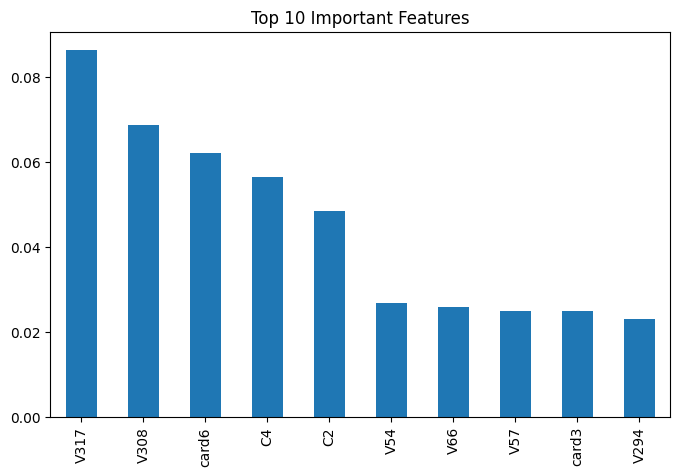

In [15]:
feature_importance = pd.Series(model.feature_importances_,index=X.columns)
top_features = feature_importance.sort_values(ascending=False).head(10)
plt.figure(figsize=(8,5))
top_features.plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()